# Sampling Distribution

Sampling Distribution is the study of a larger population by taking a smaller subset(sample).

## Access random sample from dataset

Imagine we have a population of data, and we want to random pick a small sample with size = n. To perform random sampling in python:

syntax:

Where:
* arr- 1D array
* size- sample size
* replace- True(with replacement), False(without replacement), Default is True
* p- proability assoicated with each entry, default is all equal proability 

## Access random sample from probability distribution

Imagine we have a probability distribution, and we want to random pick a small sample with size = n. To extract a small sample from the probability distribution:

syntax:

For Example, given a Standard Normal distribution, N(0,1): we want to extract a random sample of size=10

In [1]:
import scipy.stats as stats

stats.norm.rvs(loc=0, scale=1, size=10)

array([ 0.47507638, -0.15671282, -0.87409442, -2.16347806, -0.1493326 ,
       -0.56622657, -0.60168246, -0.34518434, -0.16430277,  0.65471953])

Visual representation of the random smaple of standard normal distribution:

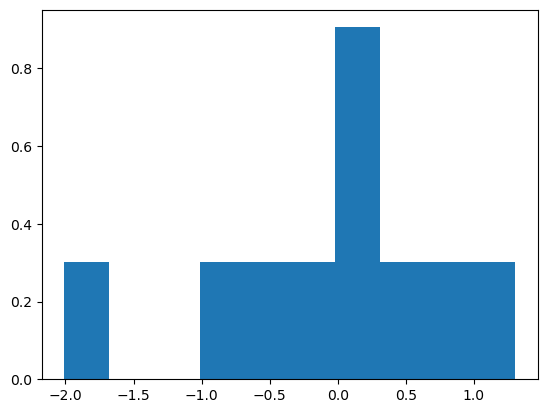

In [2]:
import matplotlib.pyplot as plt

plt.hist(
    stats.norm.rvs(loc=0, scale=1, size=10),
    label="Sample of Standard Normal Distribution with size=10",
    density=True
)

plt.show()
plt.close()

## Central Limit Theorem

Central Limit Theorem shows that:
- given a sampling distribution of size=n, if we perform the sampling distribution many times.
- The mean of the sample distribution is closed to normally distributed.
    * usually if we perform more than 30 times the mean will approximate to normal distribution

Below is the illustration in python code:

In [3]:
import scipy.stats as stats

# given a exponential distribution with lambda=5 or mean=0.2, we want to generate a random sample of size=10
exp_10 = stats.expon.rvs(scale = 1/5, size=10)
exp_10.mean()

0.14054484032346598

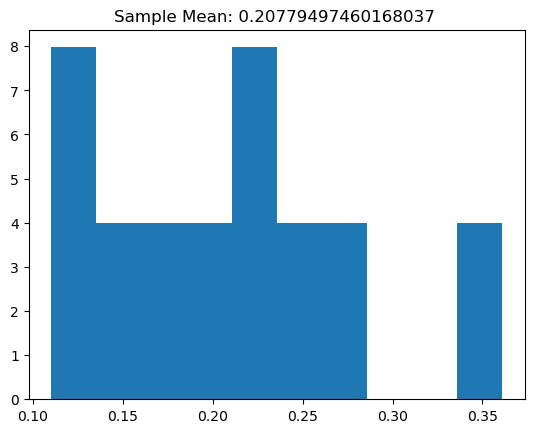

In [4]:
# let's find the mean of a random sample of exponential distirbution for 10 and see what happen:
n = 10

mean_list = []
for i in range(0,n):
    exp_10 = stats.expon.rvs(scale = 1/5, size=10)
    mean_exp_10 = exp_10.mean()
    mean_list.append(mean_exp_10)

#Let's visualize the distribution of the mean:
import matplotlib.pyplot as plt
import numpy as np

plt.title(f"Sample Mean: {np.mean(mean_list)} ")
plt.hist(
    mean_list,
    density = True
)
plt.show()
plt.close()

The distribution of the smaple mean doens't appears to be normally distributed.

Let's take a look when we perform it for 1000 times:

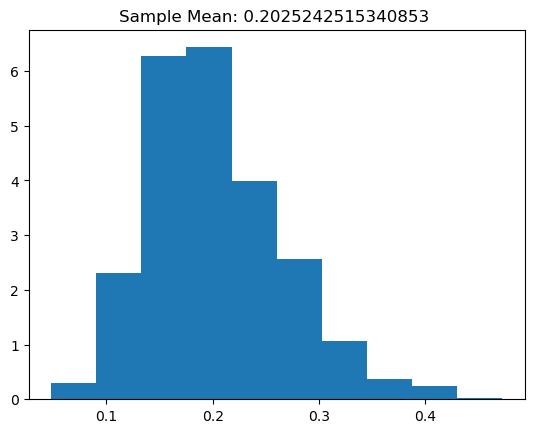

In [5]:
# let's find the mean of a random sample of exponential distirbution for 1000 and see what happen:
n = 1000

mean_list = []
for i in range(0,n):
    exp_10 = stats.expon.rvs(scale = 1/5, size=10)
    mean_exp_10 = exp_10.mean()
    mean_list.append(mean_exp_10)

#Let's visualize the distribution of the mean:
import matplotlib.pyplot as plt
import numpy as np

plt.title(f"Sample Mean: {np.mean(mean_list)} ")
plt.hist(
    mean_list,
    density = True
)
plt.show()
plt.close()

The result appears to be normal distribution with alittle bit of skewness

## Approximation of the distribution of mean

Now that we know if we have large amount of the sample mean, then the distribution of mean is approximate normal.
Then, what is the parameter of that mean normal distirbution?

The parameter of mean normal distribution is contructed by:
* sample mean (an estimation of population mean)
* standard error (an estimation of variance)

To find the sample mean:

We can just simply calculate the mean of the sample mean of each sampling distribution

To find the standard error:
    
Standard error is calculated by sample standard deviation of the mean distribution / sqrt(sample size)

To plot the approximate distribution of mean:

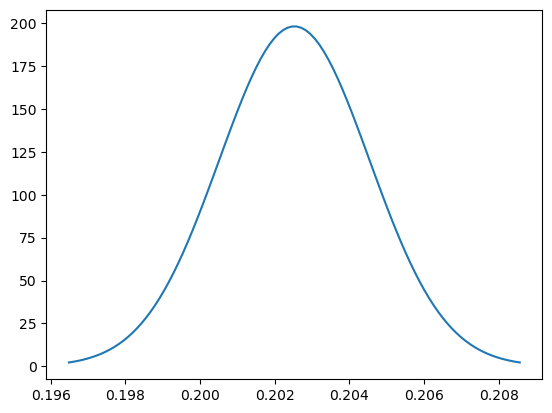

In [6]:
import numpy as np
import matplotlib.pyplot as plt

sample_mean = np.mean(mean_list)
standard_error = np.std(mean_list)/(n**0.5)

#define the range of x
x = np.linspace(sample_mean-3*standard_error, sample_mean+3*standard_error, 100)

#plot the density curve
plt.plot(
    x,
    stats.norm.pdf(x, sample_mean, standard_error),
)

plt.show()
plt.close()